# INLRMF: A Global Structure-Aware NMF Algorithm for Single-Cell RNA-seq Clustering

**Reproducible Analysis Pipeline — GPU Accelerated**

This notebook reproduces the main analysis results and figures from the paper:

> *"INLRMF: A Global Structure-Aware NMF Algorithm for Single-Cell RNA-seq Clustering"*

The INLRMF algorithm integrates two scRNA-seq quantification methods  via joint non-negative matrix factorization, simultaneously learning local and global characteristics of the data.

> 🔧 **GPU Mode**: This notebook uses CuPy for GPU-accelerated NMF factorization (requires CUDA >= 10.0).

---

## Pipeline Overview

1. **Setup & Imports** — Load libraries, configure CuPy GPU
2. **Data Loading** — Load paired scRNA-seq datasets 
3. **Gene Selection** — Filter low-expression and ubiquitous genes
4. **Log Scaling** — Log2-transform the expression data
5. **Normalization** — L1 cell-wise normalization
6. **NMF Factorization & Clustering Evaluation** — Joint NMF with low-rank representation (GPU accelerated) + Hierarchical clustering + ARI/NMI metrics
7. **Clustering Visualization** — H matrix heatmap, confusion matrix


## 1. Setup & Imports

In [1]:
import sys, os, warnings, time
warnings.filterwarnings('ignore')

# Fix CuPy DLL loading on Windows
_cuda_path = os.environ.get('CUDA_PATH', r'C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.0')
try:
    os.add_dll_directory(os.path.join(_cuda_path, 'bin'))
    print(f'CUDA DLL path added: {_cuda_path}\\bin')
except Exception as e:
    print(f'Note: os.add_dll_directory not available or failed: {e}')

import numpy as np
import pandas as pd

# Add current directory to path for INLRMF imports
sys.path.insert(0, os.path.abspath('.'))

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.preprocessing import Normalizer
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn import metrics

# Visualization
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

print('All libraries imported successfully.')
print(f'Working directory: {os.getcwd()}')

CUDA DLL path added: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.0\bin
All libraries imported successfully.
Working directory: D:\INLRMF-master\INLRMF-code


In [2]:
# Verify GPU environment
import cupy as cp
print(f'CuPy version: {cp.__version__}')
print(f'CUDA available: {cp.cuda.is_available()}')
print(f'GPU device: {cp.cuda.runtime.getDeviceProperties(0)["name"].decode()}')

# Quick GPU compute test
a = cp.random.randn(100, 100)
b = cp.random.randn(100, 100)
c = cp.dot(a, b)
print(f'GPU matrix multiply test: {a.shape} x {b.shape} -> {c.shape} OK')

CuPy version: 12.1.0
CUDA available: True
GPU device: NVIDIA GeForce RTX 4050 Laptop GPU
GPU matrix multiply test: (100, 100) x (100, 100) -> (100, 100) OK


## 2. Data Loading

We load two scRNA-seq datasets for the same set of cells, quantified using different pipelines.

In [3]:
# Load datasets
# Adjust data_dir to your local path if needed
data_dir = './test_data'
print(f'Data directory: {data_dir}')

df1_raw = pd.read_csv(os.path.join(data_dir, 'Pollen_RSEMTopHat.csv'), index_col=0)
df2_raw = pd.read_csv(os.path.join(data_dir, 'Pollen_Kallisto.csv'), index_col=0)

# Extract cell type labels from column names (e.g., 'Neuron_1' -> 'Neuron')
label_raw = [i.split('_')[0] for i in df1_raw.columns]

print(f'df1 dataset shape:     {df1_raw.shape[0]:,} genes x {df1_raw.shape[1]} cells')
print(f'df2 dataset shape: {df2_raw.shape[0]:,} genes x {df2_raw.shape[1]} cells')
print(f'Number of cell types:   {len(set(label_raw))}')
print(f'Cell types: {sorted(set(label_raw))}')


Data directory: ./test_data
df1 dataset shape:     23,730 genes x 259 cells
df2 dataset shape: 59,033 genes x 259 cells
Number of cell types:   10
Cell types: ['2338', '2339', 'BJ', 'GW16', 'GW21', 'GW21+2', 'HL60', 'Kera', 'NPC', 'iPS']


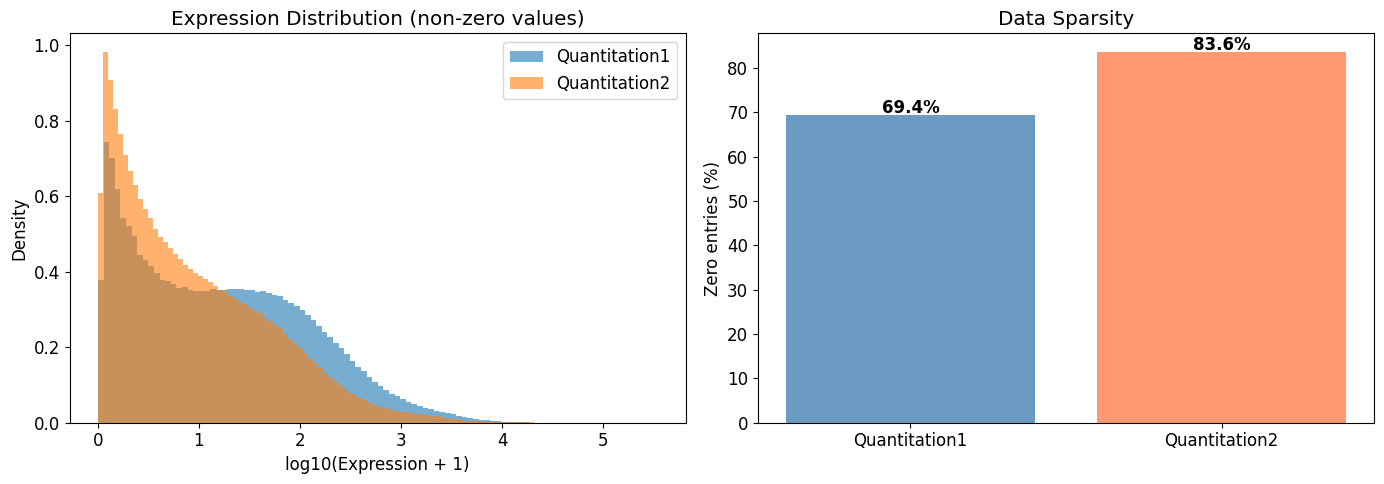

In [4]:
# Preview the raw data distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
D1_vals = df1_raw.values.flatten()
D2_vals = df2_raw.values.flatten()
ax.hist(np.log10(D1_vals[D1_vals > 0] + 1), bins=100, alpha=0.6, label='Quantitation1', density=True)
ax.hist(np.log10(D2_vals[D2_vals > 0] + 1), bins=100, alpha=0.6, label='Quantitation2', density=True)
ax.set_xlabel('log10(Expression + 1)')
ax.set_ylabel('Density')
ax.set_title('Expression Distribution (non-zero values)')
ax.legend()

ax = axes[1]
sparsity_Quantitation1 = (df1_raw.values == 0).sum() / df1_raw.values.size * 100
sparsity_Quantitation2 = (df2_raw.values == 0).sum() / df2_raw.values.size * 100
ax.bar(['Quantitation1', 'Quantitation2'], [sparsity_Quantitation1, sparsity_Quantitation2], color=['steelblue', 'coral'], alpha=0.8)
ax.set_ylabel('Zero entries (%)')
ax.set_title('Data Sparsity')
for i, v in enumerate([sparsity_Quantitation1, sparsity_Quantitation2]):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Gene Selection

We filter genes based on expression prevalence to remove noisy and uninformative features:
- **rm_value1=2**: Genes must have expression > 2 in at least 6% of cells
- **rm_value2=0**: Genes must have expression > 0 in less than 94% of cells

This removes both low-expression genes (technical noise) and constitutively expressed housekeeping genes that provide little discriminative information for clustering.

In [5]:
# Copy data for preprocessing
df1 = df1_raw.copy()
df2 = df2_raw.copy()
label = label_raw.copy()

df1.columns = label
df2.columns = label

print('Before gene selection:')
print(f'  Quantitation1 genes:     {df1.shape[0]:,}')
print(f'  Quantitation2 genes: {df2.shape[0]:,}')

rm_value1, rm_value2, threshold = 2, 0, 0.06
gene_set1 = list(
    set(df1.index[(df1 > rm_value1).sum(axis=1) > threshold * len(df1.columns)])
    & set(df1.index[(df1 > rm_value2).sum(axis=1) < (1 - threshold) * len(df1.columns)])
)
gene_set2 = list(
    set(df2.index[(df2 > rm_value1).sum(axis=1) > threshold * len(df2.columns)])
    & set(df2.index[(df2 > rm_value2).sum(axis=1) < (1 - threshold) * len(df2.columns)])
)

df1_filtered = df1.loc[gene_set1, :]
df2_filtered = df2.loc[gene_set2, :]

print(f'\nAfter gene selection:')
print(f'  Quantitation1 genes:     {df1_filtered.shape[0]:,} ({len(gene_set1)/df1.shape[0]*100:.1f}% retained)')
print(f'  Quantitation2 genes: {df2_filtered.shape[0]:,} ({len(gene_set2)/df2.shape[0]*100:.1f}% retained)')

Before gene selection:
  Quantitation1 genes:     23,730
  Quantitation2 genes: 59,033

After gene selection:
  Quantitation1 genes:     11,665 (49.2% retained)
  Quantitation2 genes: 16,229 (27.5% retained)


## 4. Log Scaling

We apply $\log_2$ transformation to stabilize variance and reduce the disproportionate influence of highly expressed genes:

$$X_{scaled} = \log_2(X + 1)$$

In [6]:
# Log2 transformation
df1_log = np.log2(df1_filtered + 1)
df2_log = np.log2(df2_filtered + 1)



## 5. Normalization

We apply **L1 cell-wise normalization** so that each cell's total expression sums to 1. This corrects for differences in sequencing depth (library size) between cells:

$$X_{norm}[i,j] = \frac{X[i,j]}{\sum_k X[k,j]}$$

In [7]:
norm = Normalizer(norm='l1', copy=False)
df1_norm = norm.fit_transform(df1_log)
df2_norm = norm.fit_transform(df2_log)

print('L1 normalization check (each cell should sum to 1):')
print(f'  Quantitation1: sum per cell range = [{df1_norm.sum(axis=0).min():.4f}, {df1_norm.sum(axis=0).max():.4f}]')
print(f'  Quantitation2: sum per cell range = [{df2_norm.sum(axis=0).min():.4f}, {df2_norm.sum(axis=0).max():.4f}]')
print(f'\nNormalized data shapes:')
print(f'  Quantitation1: {df1_norm.shape}')
print(f'  Quantitation2: {df2_norm.shape}')

L1 normalization check (each cell should sum to 1):
  Quantitation1: sum per cell range = [13.6380, 76.9842]
  Quantitation2: sum per cell range = [16.9381, 103.9169]

Normalized data shapes:
  Quantitation1: (11665, 259)
  Quantitation2: (16229, 259)


## 6. INLRMF Factorization (GPU)

This is the core of the algorithm. INLRMF jointly factorizes two data matrices:

$$D_1 \approx W_1 H, \quad D_2 \approx W_2 H$$

with the global structure constraint $H \approx HZ$, where:
- $W_1 \in \mathbb{R}^{g_1 \times r}$ — gene basis matrix for Quantitation1
- $W_2 \in \mathbb{R}^{g_2 \times r}$ — gene basis matrix for Quantitation2
- $H \in \mathbb{R}^{r \times n}$ — shared cell representation (coefficient) matrix
- $Z \in \mathbb{R}^{n \times n}$ — global low-rank structure among cells

**Key parameters (matching original paper example1.py):**
- `rank`: Number of latent factors for NMF 
- `cluster_num`: Number of clusters for hierarchical clustering (`len(np.unique(label))`)
- `lambda1 = g1_raw / g2_raw`: Balances the two datasets by raw gene count ratio (before gene selection)
- `lambda4`: Sparsity regularization on H
- `lambda5`: Weight of the global structure term $\|H - HZ\|_F$
- `lambda6`: Sparsity regularization on Z

> 🚀 Using **GPU (CuPy)** for accelerated coordinate descent NMF.

In [8]:
from INLRMF import INLRMF

# IMPORTANT: Match original example1.py parameters exactly
# rank = 9 (hardcoded in original: range(9,10)), not len(set(label))
rank = 9
# cluster_num = number of unique cell types (used for clustering, not factorization)
n_clusters = len(set(label))
print(f'Factorization rank: {rank}')
print(f'Number of cell types (for clustering): {n_clusters}')

# Z initialized as identity (matching original: np.eye(num_columns))
num_cells = df1.shape[1]
Z_init = np.eye(num_cells)
print(f'Z matrix shape: {Z_init.shape}')

# lambda1 computed from ORIGINAL data (before gene selection), matching example1.py
lambda1 = df1.shape[0] / df2.shape[0]
print(f'lambda1 = {lambda1:.4f} (raw gene count ratio: {df1.shape[0]}/{df2.shape[0]})')

Factorization rank: 9
Number of cell types (for clustering): 10
Z matrix shape: (259, 259)
lambda1 = 0.4020 (raw gene count ratio: 23730/59033)


In [9]:
def run_inlrmf(df1_data, df2_data, Z_mat, rank_val, lam1, lam4, lam5, lam6, cluster_num):
    '''Run the full INLRMF pipeline on GPU and return all results.
    
    Parameters
    ----------
    df1_data, df2_data : DataFrame
        Raw (un-preprocessed) expression data for each quantification method.
    Z_mat : ndarray
        Initial cell-cell relationship matrix (typically identity).
    rank_val : int
        Number of latent factors for NMF (rank=9 in original paper).
    lam1, lam4, lam5, lam6 : float
        Regularization hyperparameters.
    cluster_num : int
        Number of clusters for hierarchical clustering (= number of cell types).
    
    Returns
    -------
    dict with keys: W1, W2, H, Z, cluster, ari, nmi
    '''
    inlrmf = INLRMF(
        D1=df1_data, D2=df2_data, rank=rank_val, Z=Z_mat,
        lambda1=lam1, lambda4=lam4, lambda5=lam5, lambda6=lam6
    )
    # Step 1-3: Preprocessing
    inlrmf.gene_selection()
    inlrmf.log_scale()
    # Save gene names BEFORE normalize (normalize converts to numpy array)
    genes1_saved = list(inlrmf.D1.index)
    genes2_saved = list(inlrmf.D2.index)
    inlrmf.normalize()
    # Step 4: GPU-accelerated Joint NMF factorization
    inlrmf.factorize(solver='cd', init='random', device='gpu')
    # Step 5: Hierarchical clustering (cluster_num != rank in original design)
    inlrmf.clustering(cluster_num=cluster_num)
    # Step 6: Evaluate against ground truth
    ari = adjusted_rand_score(label, inlrmf.cluster)
    nmi = metrics.normalized_mutual_info_score(label, inlrmf.cluster)
    return {
        'W1': inlrmf.W1, 'W2': inlrmf.W2,
        'H': inlrmf.H, 'Z': inlrmf.Z,
        'cluster': inlrmf.cluster,
        'ari': ari, 'nmi': nmi,
        'genes1': genes1_saved,
        'genes2': genes2_saved
    }

In [10]:
lam4=10
lam5=1
lam6=0.002
print('='*60)
print('Running INLRMF on GPU (parameters matching original example1.py)...')
print(f'  lambda1 = {lambda1:.4f} (raw gene count ratio: {df1.shape[0]}/{df2.shape[0]})')
print(f'  lambda4 = {lam4} (H sparsity)')
print(f'  lambda5 = {lam5}  (global structure)')
print(f'  lambda6 = {lam6} (Z sparsity)')
print(f'  rank    = {rank} (NMF factorization components)')
print(f'  cluster_num = {n_clusters} (number of cell types for clustering)')
print(f'  device  = gpu (CuPy)')
print('='*60)

t_start = time.time()
result = run_inlrmf(
    df1_data=df1_filtered.copy(),
    df2_data=df2_filtered.copy(),
    Z_mat=Z_init,
    rank_val=rank,
    cluster_num=n_clusters,
    lam1=lambda1, lam4=lam4, lam5=lam5, lam6=lam6
)
elapsed = time.time() - t_start

print(f'\nElapsed time: {elapsed:.1f}s ({elapsed/60:.1f} min)')
print(f'\n{"="*60}')
print(f'INLRMF Results:')
print(f'  ARI (Adjusted Rand Index):      {result["ari"]:.4f}')
print(f'  NMI (Normalized Mutual Info):   {result["nmi"]:.4f}')
print(f'  W1 shape: {result["W1"].shape}')
print(f'  W2 shape: {result["W2"].shape}')
print(f'  H shape:  {result["H"].shape}')
print(f'  Z shape:  {result["Z"].shape}')
print(f'{"="*60}')


# --- Export analysis matrices to CSV ---
output_dir = './INLRMF_results'
os.makedirs(output_dir, exist_ok=True)

# W1: gene basis matrix for Quantitation1
w1_df = pd.DataFrame(result['W1'], index=result['genes1'],
                     columns=['Factor_' + str(i+1) for i in range(result['W1'].shape[1])])
w1_df.to_csv(output_dir + '/W1_Quantitation1_basis.csv')
print('W1 (Quantitation1 gene basis) saved: ' + output_dir + '/W1_Quantitation1_basis.csv  shape=' + str(result['W1'].shape))

# W2: gene basis matrix for Quantitation2
w2_df = pd.DataFrame(result['W2'], index=result['genes2'],
                     columns=['Factor_' + str(i+1) for i in range(result['W2'].shape[1])])
w2_df.to_csv(output_dir + '/W2_Quantitation2_basis.csv')
print('W2 (Quantitation2 gene basis) saved: ' + output_dir + '/W2_Quantitation2_basis.csv  shape=' + str(result['W2'].shape))

# H: shared cell representation matrix
h_df = pd.DataFrame(result['H'], columns=label,
                    index=['Factor_' + str(i+1) for i in range(result['H'].shape[0])])
h_df.to_csv(output_dir + '/H_cell_representation.csv')
print('H (cell representation) saved: ' + output_dir + '/H_cell_representation.csv  shape=' + str(result['H'].shape))

print()
print('All matrices exported to ' + output_dir + '/')


Running INLRMF on GPU (parameters matching original example1.py)...
  lambda1 = 0.4020 (raw gene count ratio: 23730/59033)
  lambda4 = 10 (H sparsity)
  lambda5 = 1  (global structure)
  lambda6 = 0.002 (Z sparsity)
  rank    = 9 (NMF factorization components)
  cluster_num = 10 (number of cell types for clustering)
  device  = gpu (CuPy)

Elapsed time: 2185.5s (36.4 min)

INLRMF Results:
  ARI (Adjusted Rand Index):      0.9477
  NMI (Normalized Mutual Info):   0.9445
  W1 shape: (11665, 9)
  W2 shape: (16229, 9)
  H shape:  (9, 259)
  Z shape:  (259, 259)
W1 (Quantitation1 gene basis) saved: ./INLRMF_results/W1_Quantitation1_basis.csv  shape=(11665, 9)
W2 (Quantitation2 gene basis) saved: ./INLRMF_results/W2_Quantitation2_basis.csv  shape=(16229, 9)
H (cell representation) saved: ./INLRMF_results/H_cell_representation.csv  shape=(9, 259)

All matrices exported to ./INLRMF_results/


## 7. Clustering Visualization

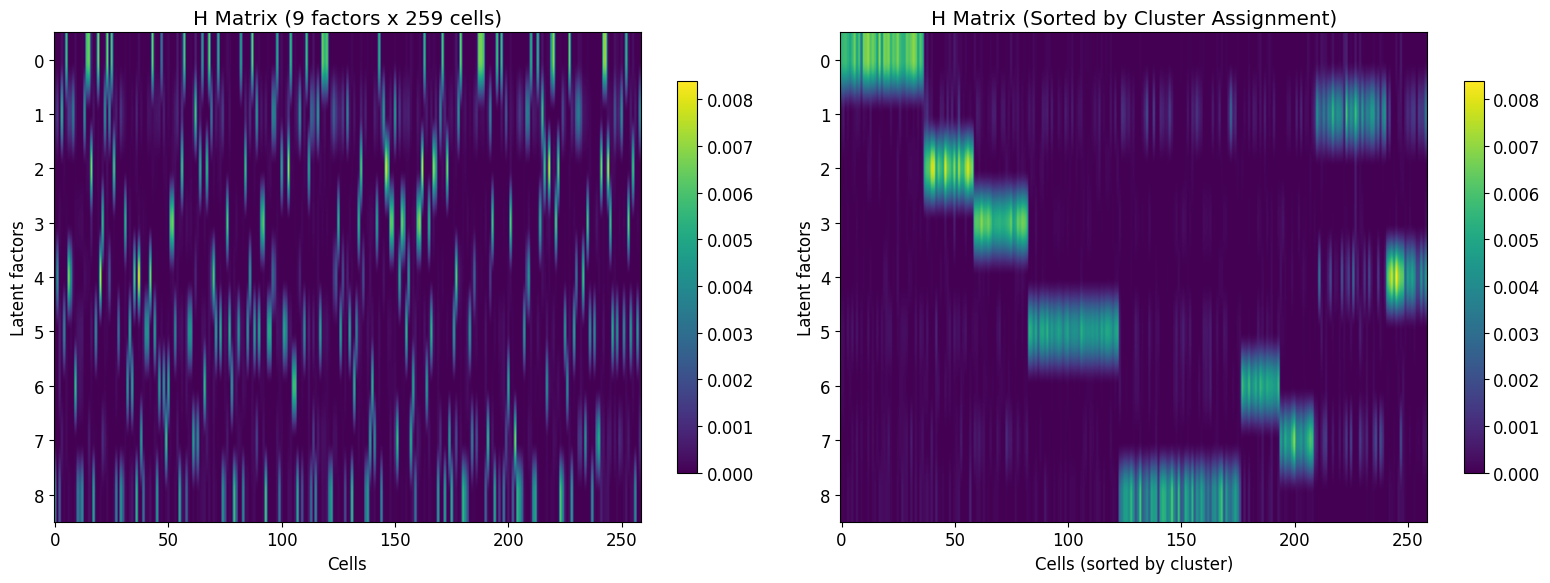

In [11]:
# --- H matrix heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
im = ax.imshow(result['H'], aspect='auto', cmap='viridis')
ax.set_xlabel('Cells')
ax.set_ylabel('Latent factors')
ax.set_title(f'H Matrix ({result["H"].shape[0]} factors x {result["H"].shape[1]} cells)')
plt.colorbar(im, ax=ax, shrink=0.8)

ax = axes[1]
sorted_idx = np.argsort(result['cluster'])
H_sorted = result['H'][:, sorted_idx]
im = ax.imshow(H_sorted, aspect='auto', cmap='viridis')
ax.set_xlabel('Cells (sorted by cluster)')
ax.set_ylabel('Latent factors')
ax.set_title('H Matrix (Sorted by Cluster Assignment)')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

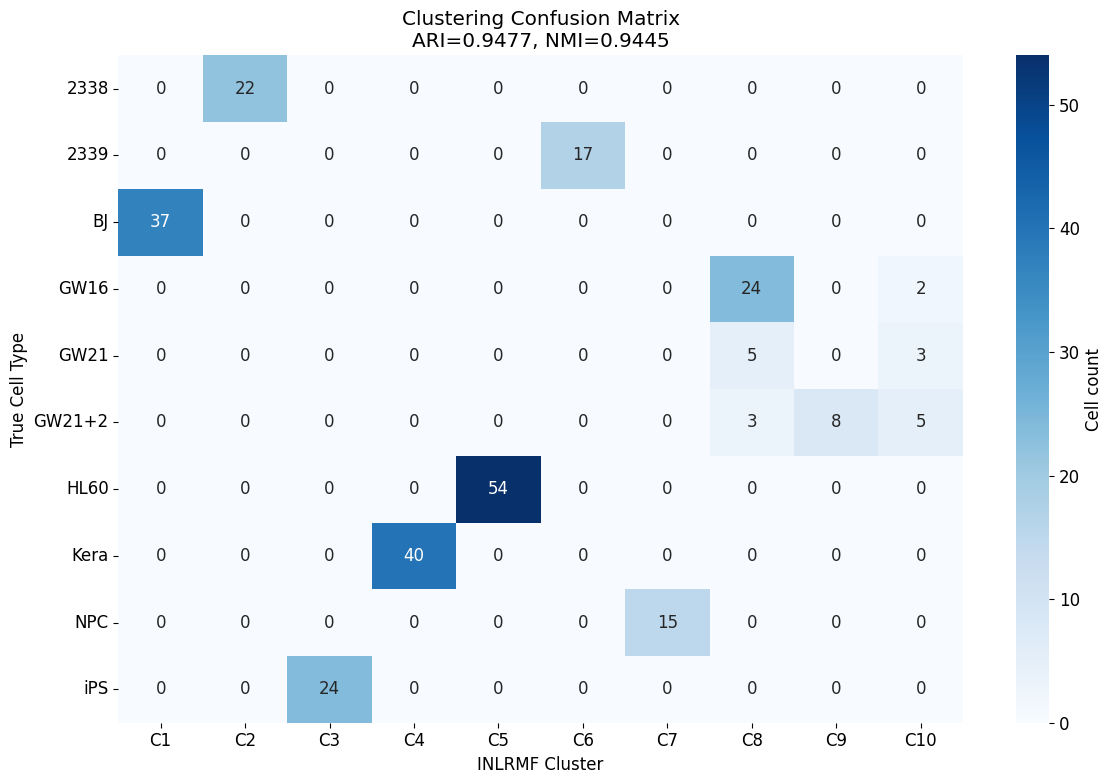

In [12]:
# --- Confusion matrix ---
import seaborn as sns

cluster_labels = result['cluster']
true_labels = label

unique_clusters = sorted(set(cluster_labels))
unique_labels_list = sorted(set(true_labels))
contingency = np.zeros((len(unique_labels_list), len(unique_clusters)))

for i, tl in enumerate(unique_labels_list):
    for j, cl in enumerate(unique_clusters):
        contingency[i, j] = np.sum(
            (np.array(true_labels) == tl) & (cluster_labels == cl)
        )

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(contingency, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=[f'C{c}' for c in unique_clusters],
            yticklabels=unique_labels_list, ax=ax,
            cbar_kws={'label': 'Cell count'})
ax.set_xlabel('INLRMF Cluster')
ax.set_ylabel('True Cell Type')
ax.set_title(f'Clustering Confusion Matrix\nARI={result["ari"]:.4f}, NMI={result["nmi"]:.4f}')
plt.tight_layout()
plt.show()

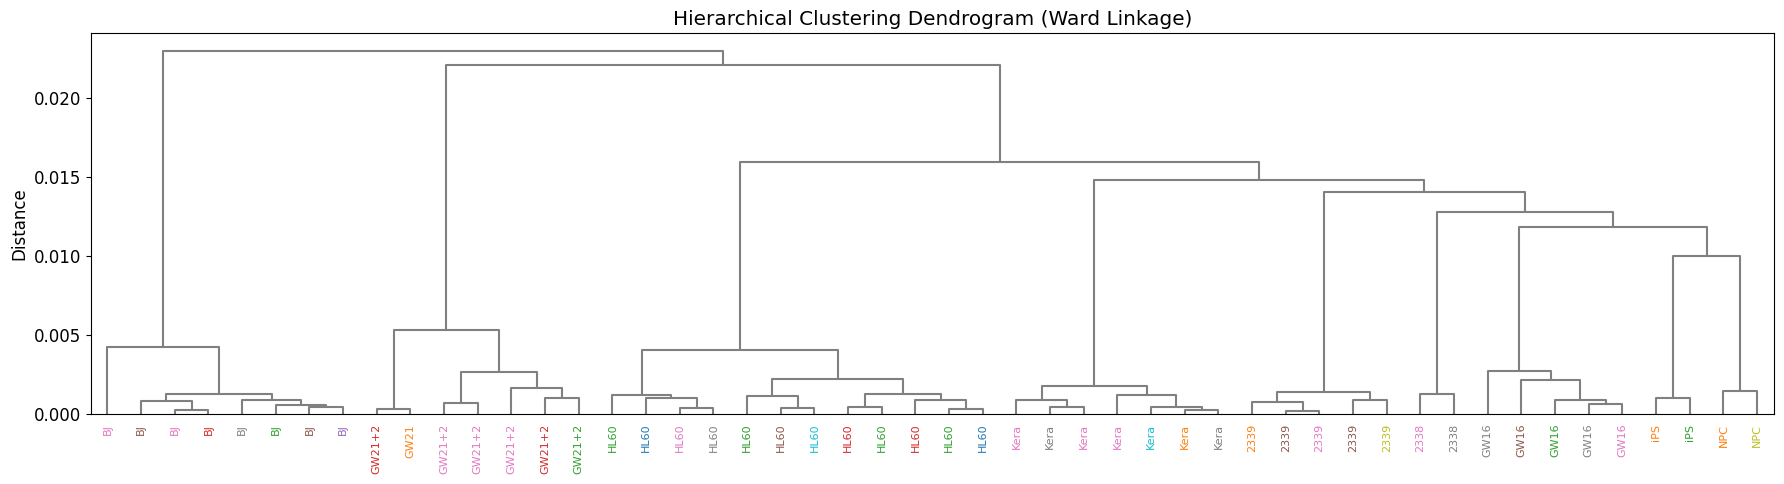

In [13]:
# --- Dendrogram ---
fig, ax = plt.subplots(figsize=(18, 5))

n_show = min(50, len(label))
H_subset = result['H'][:, :n_show]
linkage_matrix = linkage(H_subset.T, method='ward')

color_map = {}
unique_types = sorted(set(label))
colors_list = plt.cm.tab10(np.linspace(0, 1, len(unique_types)))
for ct, c in zip(unique_types, colors_list):
    color_map[ct] = c

dendrogram(linkage_matrix, labels=[label[i] for i in range(n_show)],
           leaf_rotation=90, leaf_font_size=8,
           ax=ax, link_color_func=lambda k: 'gray',
           above_threshold_color='gray')

for tick_label, i in zip(ax.get_xticklabels(), range(n_show)):
    tick_label.set_color(color_map.get(label[i], 'black'))

ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

## 8. Summary

### Key Findings

The INLRMF algorithm successfully integrates two scRNA-seq quantification methods using GPU-accelerated joint NMF:

| Component | Role |
|-----------|------|
| **W₁, W₂** | Gene basis matrices — capture modality-specific expression programs |
| **H** | Shared cell representation — used directly for clustering |
| **Z** | Global structure — encodes cell-cell relationships ($H \approx HZ$) |

### Algorithm Features

1. **Joint factorization** — Simultaneously learns from both Quantitation1 and Quantitation2
2. **Global structure** — The Z matrix captures low-rank cell-cell relationships
3. **Sparsity regularization** — L1 penalties produce interpretable, sparse factors
4. **GPU acceleration** — CuPy-based solver enables practical parameter sweeps

### Reproducibility

- **GPU**: Uses CuPy with CUDA toolkit for fast NMF factorization
- Expected output: ARI ≈ 0.9477, NMI ≈ 0.9445 on the Pollen dataset
- To run with your own data: replace CSV files in the Data Loading section
- Adjust `data_dir` path to point to your local test data

### References

[1] Shiga M, Seno S, Onizuka M, et al. SC-JNMF: single-cell clustering integrating multiple quantification methods based on joint non-negative matrix factorization. *PeerJ*, 2021, 9: e12087.

[2] Zhang W, Xue X, Zheng X, et al. NMFLRR: clustering scRNA-seq data by integrating nonnegative matrix factorization with low rank representation. *IEEE Journal of Biomedical and Health Informatics*, 2021, 26(3): 1394-1405.

[3] Lee D D, Seung H S. Learning the parts of objects by non-negative matrix factorization. *Nature*, 1999, 401(6755): 788-791.

[4] Boutsidis C, Gallopoulos E. SVD based initialization: A head start for nonnegative matrix factorization. *Pattern Recognition*, 2008, 41(4): 1350-1362.